Read Data and Handle Missing Values

In [33]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as skl
import numpy as np
import seaborn as sns
from pathlib import Path

df = pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [34]:
df.drop(columns=['encounter_id', 'patient_nbr','weight','examide', 'citoglipton'], inplace=True)
# Encounter_id and patient number are irrelevant for the output
# weight is over 90% empty
# examide and citoglipton both have no variance whatsoever
df = df.replace('?', np.nan)
df.head()
df.isnull().sum()
# replacing all '?' with nan so that we can count all the missing values
df.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'], inplace=True)
# removing the rows with null values
df.isnull().sum()

race                            0
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  38924
medical_specialty           48318
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               92845
A1Cresult                   81860
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide   

In [35]:
# since the rest of the missing columns are relevant to the output we cannot drop them instead filling each with what its missing
df['payer_code'] = df['payer_code'].fillna('not specified')
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not Measured')
df['A1Cresult'] = df['A1Cresult'].fillna('Not Measured')
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
# check for any missing values
df.drop_duplicates(inplace=True)
df.isnull().sum()


race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol  

Cleaning + Encoding 

In [36]:
df['medical_specialty'].value_counts()
# display the medical specialties values to pick the most relevant 10

medical_specialty
Unknown                             48318
InternalMedicine                    13967
Emergency/Trauma                     7472
Family/GeneralPractice               7140
Cardiology                           5218
                                    ...  
Psychiatry-Addictive                    1
Perinatology                            1
Neurophysiology                         1
Pediatrics-InfectiousDiseases           1
Surgery-PlasticwithinHeadandNeck        1
Name: count, Length: 73, dtype: int64

In [37]:
top_10_specialties = df['medical_specialty'].value_counts().head(10).index
df.loc[~df['medical_specialty'].isin(top_10_specialties), 'medical_specialty'] = 'Other'

In [38]:
# find a pattern in a medicine column ex.: metformin
df['metformin'].value_counts()

metformin
No        78808
Steady    17677
Up         1017
Down        551
Name: count, dtype: int64

Mapping 

In [39]:
# identify all the medicine columns
medication_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 
    'miglitol', 'troglitazone', 'tolazamide', 'insulin', 
    'glyburide-metformin', 'glipizide-metformin', 
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 
    'metformin-pioglitazone'
]
# since all the medication columns have the same 4 measurements we map them
med_mapping = {'No': 0, 'Down': 1, 'Steady': 2, 'Up': 3}
df['metformin'] = df['metformin'].map(med_mapping)

for col in medication_columns:
    df[col] = df[col].map(med_mapping)

In [40]:
age_mapping = {
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9
}

df['age'] = df['age'].map(age_mapping)

In [41]:
# map these test results into 3 categories
a1c_mapping = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
glu_mapping = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}

df['A1Cresult'] = df['A1Cresult'].map(a1c_mapping)
df['max_glu_serum'] = df['max_glu_serum'].map(glu_mapping)

In [42]:
# Map 'change' (No change vs. Change)
change_mapping = {'No': 0, 'Ch': 1}
df['change'] = df['change'].map(change_mapping)

# Map 'diabetesMed' (No medication vs. Yes medication)
diab_med_mapping = {'No': 0, 'Yes': 1}
df['diabetesMed'] = df['diabetesMed'].map(diab_med_mapping)

In [43]:
# After looking up what each diagnosis code means we decided to narrow it down to 9 major diseases
# making it easier to categorize rather than it being continuous values that the model wont understand then later on we encode them
def group_diagnosis(code):
    
    code = str(code).upper()
    
    # V and E codes go into the 'Other' bucket
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    
    # Group the numeric codes by their ICD-9 disease ranges
    try:
        num = float(code)
        if 250 <= num < 251:
            return 'Diabetes'
        elif (390 <= num <= 459) or num == 785:
            return 'Circulatory'
        elif (460 <= num <= 519) or num == 786:
            return 'Respiratory'
        elif (520 <= num <= 579) or num == 787:
            return 'Digestive'
        elif 800 <= num <= 999:
            return 'Injury'
        elif 710 <= num <= 739:
            return 'Musculoskeletal'
        elif (580 <= num <= 629) or num == 788:
            return 'Genitourinary'
        elif 140 <= num <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except ValueError:
        return 'Other'

# Apply this function to all three diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(group_diagnosis)

In [44]:
#final result mapping the supposed output into 3 classes
multi_class_mapping = {'NO': 0, '>30': 1, '<30': 2}
df['readmitted'] = df['readmitted'].map(multi_class_mapping)

One Hot Encoding

In [45]:
# final step for categorical data / nominal data to make sense
nominal_columns = ['race', 'gender', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
df = pd.get_dummies(df, columns=nominal_columns, dtype=int)
df.head()


,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,diag_2_Respiratory,diag_3_Circulatory,diag_3_Diabetes,diag_3_Digestive,diag_3_Genitourinary,diag_3_Injury,diag_3_Musculoskeletal,diag_3_Neoplasms,diag_3_Other,diag_3_Respiratory
1,1,1,1,7,3,59,0,18,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2,1,1,7,2,11,5,13,2,0,...,0,0,0,0,0,0,0,0,1,0
3,3,1,1,7,2,44,1,16,0,0,...,0,1,0,0,0,0,0,0,0,0
4,4,1,1,7,1,51,0,8,0,0,...,0,0,1,0,0,0,0,0,0,0
5,5,2,1,2,3,31,6,16,0,0,...,0,0,1,0,0,0,0,0,0,0


In [46]:
#check that everything is numerical + check number of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98053 entries, 1 to 101765
Columns: 101 entries, age to diag_3_Respiratory
dtypes: float64(3), int32(63), int64(35)
memory usage: 52.7 MB


In [47]:
# The 9 categories we created earlier will be mapped into 9 columns instead of 27 in order to reduce the total number of columns
disease_categories = ['Diabetes', 'Circulatory', 'Respiratory', 'Digestive', 
                      'Injury', 'Musculoskeletal', 'Genitourinary', 'Neoplasms', 
                      'Other']

for disease in disease_categories:
    cols_to_check = [f'diag_1_{disease}', f'diag_2_{disease}', f'diag_3_{disease}']
    
    # Valid columns condition to fix an error with pandas libarary
    valid_cols = [col for col in cols_to_check if col in df.columns]
    
    if valid_cols:
        df[f'has_{disease}'] = df[valid_cols].max(axis=1)
        df.drop(columns=valid_cols, inplace=True)

In [48]:
df.head()

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,medical_specialty_Unknown,has_Diabetes,has_Circulatory,has_Respiratory,has_Digestive,has_Injury,has_Musculoskeletal,has_Genitourinary,has_Neoplasms,has_Other
1,1,1,1,7,3,59,0,18,0,0,...,1,1,0,0,0,0,0,0,0,1
2,2,1,1,7,2,11,5,13,2,0,...,1,1,0,0,0,0,0,0,0,1
3,3,1,1,7,2,44,1,16,0,0,...,1,1,1,0,0,0,0,0,0,1
4,4,1,1,7,1,51,0,8,0,0,...,1,1,0,0,0,0,0,0,1,0
5,5,2,1,2,3,31,6,16,0,0,...,1,1,1,0,0,0,0,0,0,0


Visiualisation

C:\Users\Jana\AppData\Local\Temp\ipykernel_36344\2194237530.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='readmitted', data=df, order=[0,1,2], palette='viridis')
C:\Users\Jana\AppData\Local\Temp\ipykernel_36344\2194237530.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['NO', '>30', '<30'])


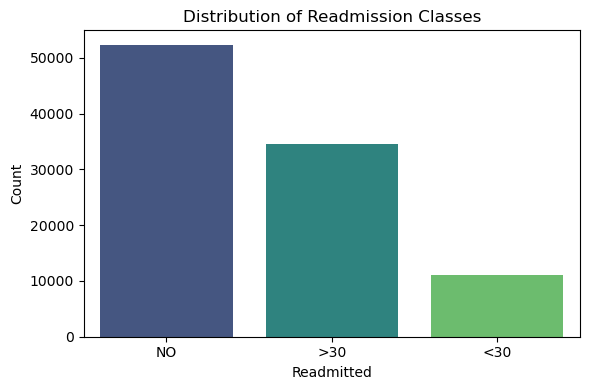

In [49]:
# 1) Distribution of the target variable (readmitted)

plt.figure(figsize=(6,4))
ax = sns.countplot(x='readmitted', data=df, order=[0,1,2], palette='viridis')
ax.set_xticklabels(['NO', '>30', '<30'])
plt.title('Distribution of Readmission Classes')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


C:\Users\Jana\AppData\Local\Temp\ipykernel_36344\567805705.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age', data=df, palette='mako')


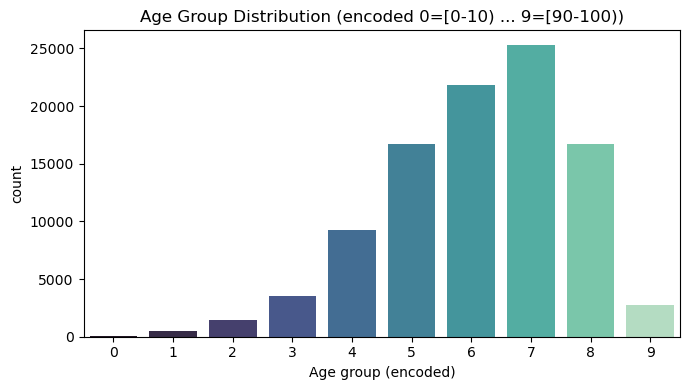

In [50]:
# 2) Age group distribution

plt.figure(figsize=(7,4))
sns.countplot(x='age', data=df, palette='mako')
plt.title('Age Group Distribution (encoded 0=[0-10) ... 9=[90-100))')
plt.xlabel('Age group (encoded)')
plt.tight_layout()
plt.show()


C:\Users\Jana\AppData\Local\Temp\ipykernel_36344\3519764440.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='time_in_hospital', data=df, palette='Set2')


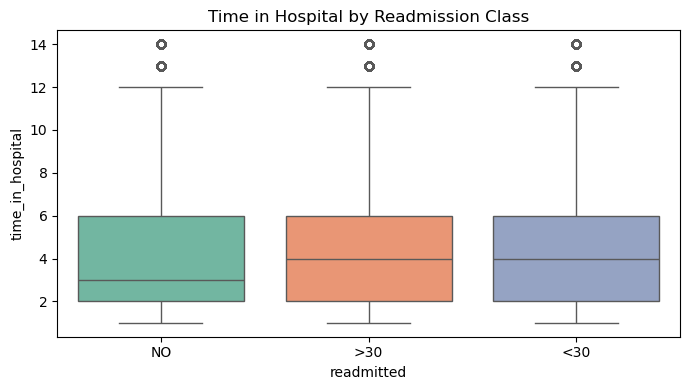

In [51]:
# 3) Time spent in hospital by readmission class

plt.figure(figsize=(7,4))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df, palette='Set2')
plt.xticks([0,1,2], ['NO', '>30', '<30'])
plt.title('Time in Hospital by Readmission Class')
plt.tight_layout()
plt.show()


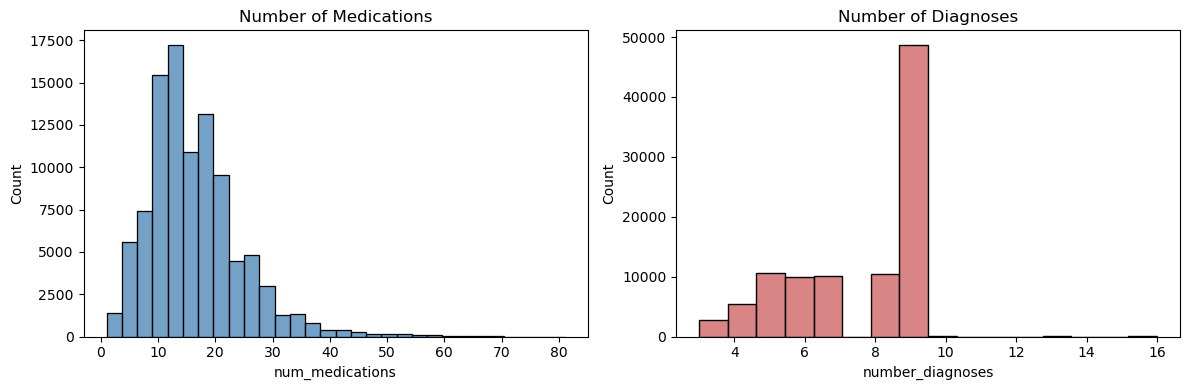

In [52]:
# 4) Number of medications and number of diagnoses vs. length of stay

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['num_medications'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Number of Medications')
sns.histplot(df['number_diagnoses'], bins=16, ax=axes[1], color='indianred')
axes[1].set_title('Number of Diagnoses')
plt.tight_layout()
plt.show()


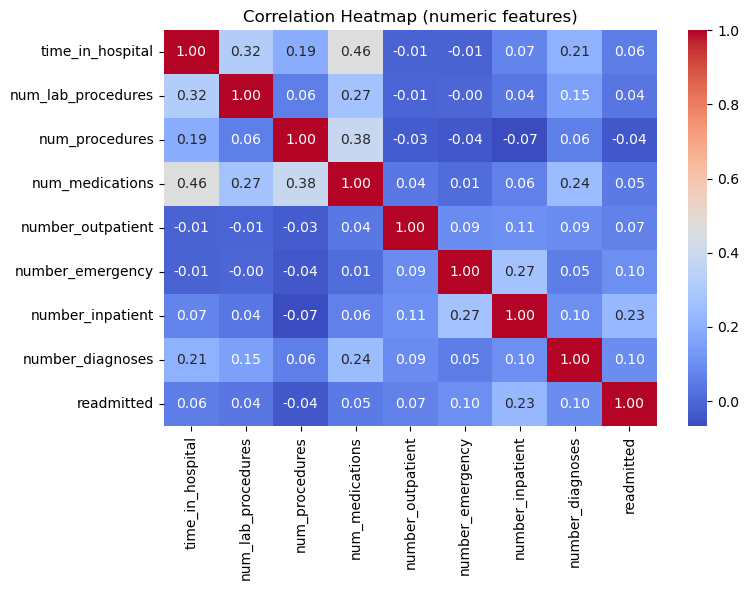

In [53]:
# 5) Correlation heatmap between the main numeric variables

numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                 'num_medications', 'number_outpatient', 'number_emergency',
                 'number_inpatient', 'number_diagnoses', 'readmitted']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (numeric features)')
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

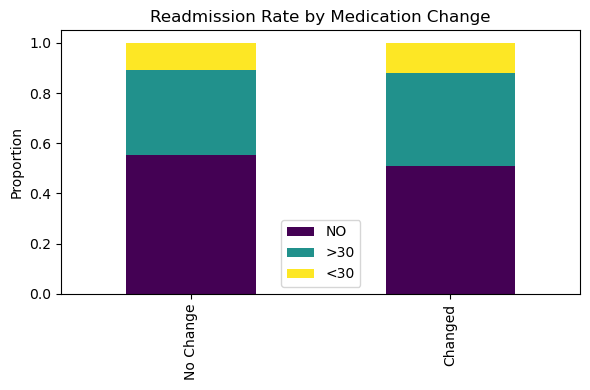

In [54]:
# 6) Does a medication change relate to readmission?

plt.figure(figsize=(6,4))
ct = pd.crosstab(df['change'], df['readmitted'], normalize='index')
ct.columns = ['NO', '>30', '<30']
ct.index = ['No Change', 'Changed']
ct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(6,4))
plt.title('Readmission Rate by Medication Change')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()


Train / Test split


In [55]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['readmitted'])
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print(y_train.value_counts(normalize=True))


Train shape: (78442, 82)
Test shape : (19611, 82)
readmitted
0    0.533770
1    0.353369
2    0.112860
Name: proportion, dtype: float64


Scaling (Min - Max)

In [56]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


c:\Users\Jana\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:701: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\Jana\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:718: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print('Random Forest Results')
print('Accuracy :', accuracy_score(y_test, rf_pred))
print('F1 (macro):', f1_score(y_test, rf_pred, average='macro'))
print(classification_report(y_test, rf_pred, target_names=['NO', '>30', '<30']))


Random Forest Results
Accuracy : 0.5799806231196777
F1 (macro): 0.3713681138464089
              precision    recall  f1-score   support

          NO       0.60      0.87      0.71     10468
         >30       0.51      0.33      0.40      6930
         <30       0.57      0.00      0.00      2213

    accuracy                           0.58     19611
   macro avg       0.56      0.40      0.37     19611
weighted avg       0.57      0.58      0.52     19611



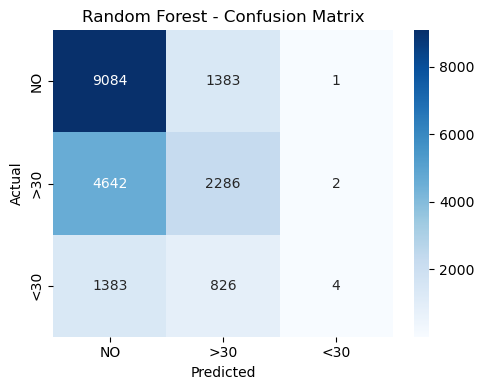

In [58]:
# Confusion matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO','>30','<30'], yticklabels=['NO','>30','<30'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

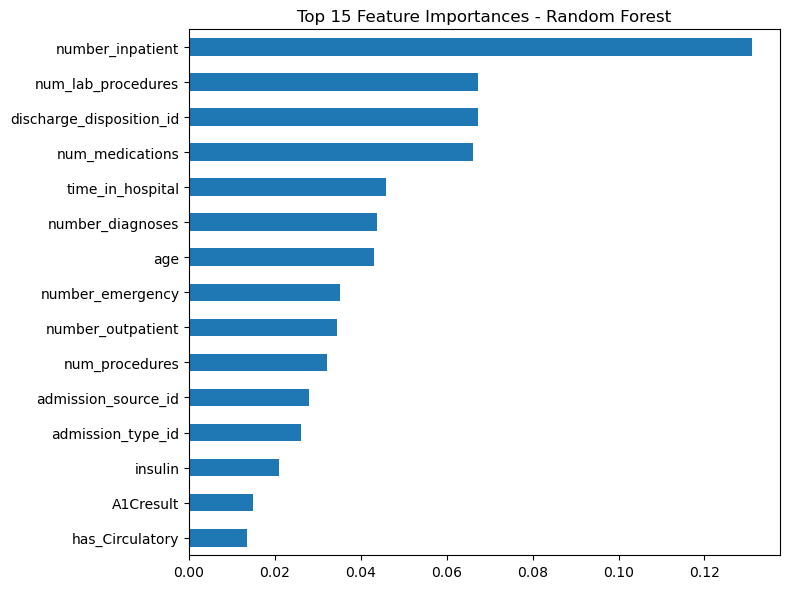

In [59]:
#Most important feature according to Random Forest

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()


Neural Network


In [60]:
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer

nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu', max_iter=150,
    random_state=42, early_stopping=True
)
# Fill missing values before scaling/training
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Rebuild scaled features
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Train the neural network
nn_model.fit(X_train_scaled, y_train)
nn_pred = nn_model.predict(X_test_scaled)

print('Neural Network Results')
print('Accuracy :', accuracy_score(y_test, nn_pred))
print('F1 (macro):', f1_score(y_test, nn_pred, average='macro'))
print(classification_report(y_test, nn_pred, target_names=['NO', '>30', '<30']))


Neural Network Results
Accuracy : 0.5743715261842843
F1 (macro): 0.3833163051137886
              precision    recall  f1-score   support

          NO       0.60      0.84      0.70     10468
         >30       0.50      0.35      0.41      6930
         <30       0.45      0.02      0.04      2213

    accuracy                           0.57     19611
   macro avg       0.52      0.40      0.38     19611
weighted avg       0.55      0.57      0.52     19611



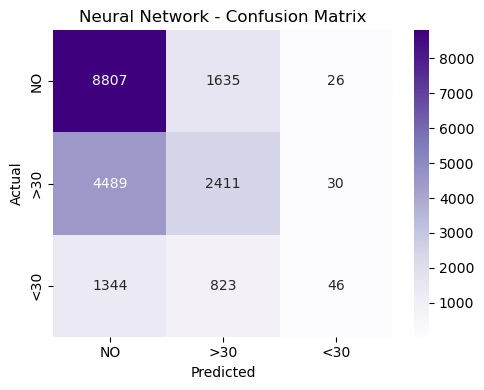

In [61]:
# Confusion matrix - Neural Network


cm_nn = confusion_matrix(y_test, nn_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['NO','>30','<30'], yticklabels=['NO','>30','<30'])
plt.title('Neural Network - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


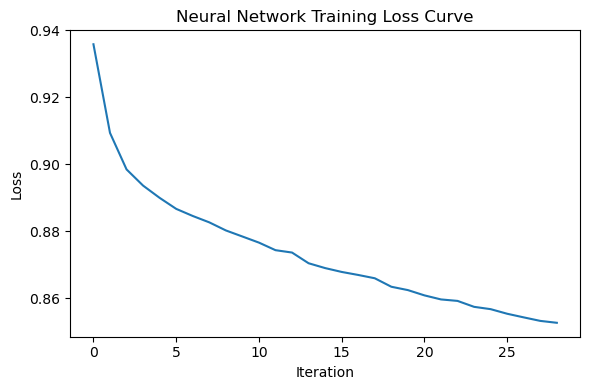

In [62]:
#(Loss curve) while traning 

plt.figure(figsize=(6,4))
plt.plot(nn_model.loss_curve_)
plt.title('Neural Network Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()


Compare Results Of Random Forest & Neural Network


In [63]:
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Network'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, nn_pred)],
    'F1 (macro)': [f1_score(y_test, rf_pred, average='macro'), f1_score(y_test, nn_pred, average='macro')],
    'Precision (macro)': [precision_score(y_test, rf_pred, average='macro'), precision_score(y_test, nn_pred, average='macro')],
    'Recall (macro)': [recall_score(y_test, rf_pred, average='macro'), recall_score(y_test, nn_pred, average='macro')],
})
results_df


,Model,Accuracy,F1 (macro),Precision (macro),Recall (macro)
0,Random Forest,0.579981,0.371368,0.560408,0.399822
1,Neural Network,0.574372,0.383316,0.515908,0.403340


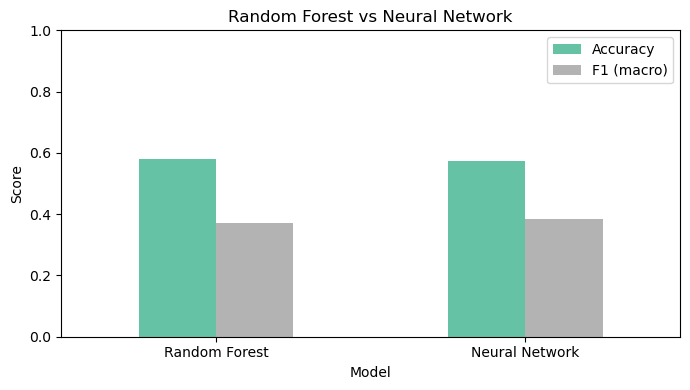

In [64]:
results_df.set_index('Model')[['Accuracy', 'F1 (macro)']].plot(kind='bar', figsize=(7,4), colormap='Set2')
plt.title('Random Forest vs Neural Network')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
